EMPLOYEE ATTRITION 

C:\Users\anusr\AppData\Local\Temp\ipykernel_29368\40801090.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_rate.index,y=attrition_rate.values,palette=["#1d7874","#8B0000"])


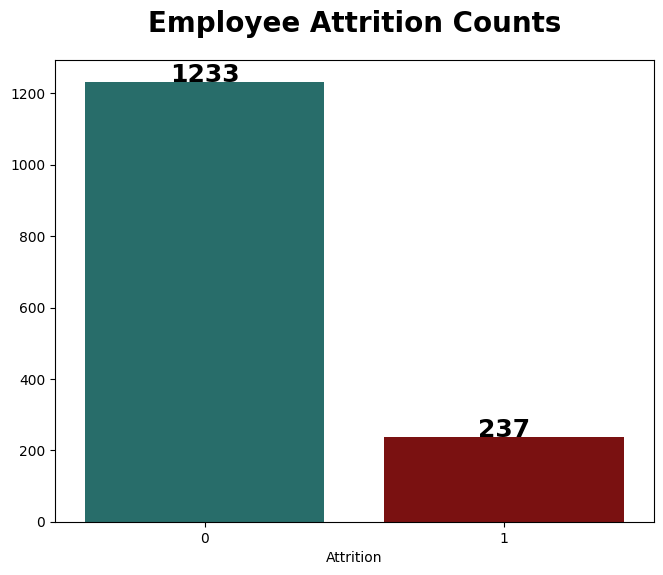

In [7]:
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(17,6))
plt.subplot(1,2,1)
attrition_rate = df["Attrition"].value_counts()
sns.barplot(x=attrition_rate.index,y=attrition_rate.values,palette=["#1d7874","#8B0000"])
plt.title("Employee Attrition Counts",fontweight="black",size=20,pad=20)
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v, v,ha="center", fontweight='black', fontsize=18)

plt.show()

([<matplotlib.patches.Wedge at 0x2bf5a26bcb0>,
 [Text(-1.0461620947148778, -0.33991891912892863, 'Male'),
  Text(1.1412678840917598, 0.370820194623645, 'Female')],
 [Text(-0.5706338698444787, -0.18541031952487017, '60%'),
  Text(0.6657395990535264, 0.21631178019712624, '40%')])

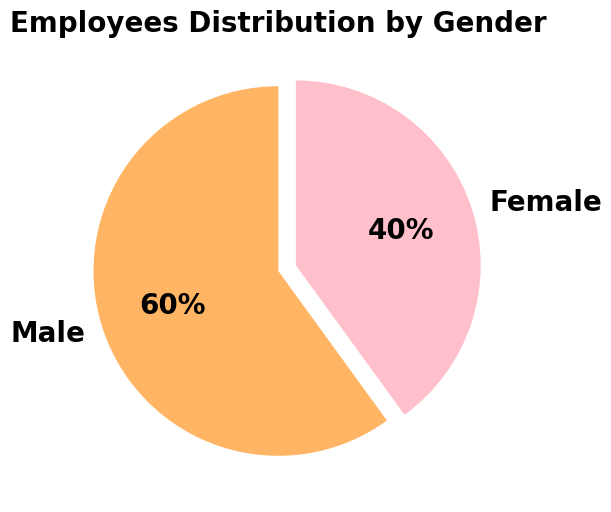

In [8]:

#Visualization to show Total Employees by Gender.
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
gender_attrition = df["Gender"].value_counts()
plt.title("Employees Distribution by Gender",fontweight="black",size=20)
plt.pie(gender_attrition, autopct="%.0f%%",labels=gender_attrition.index,textprops=({"fontweight":"black","size":20}),
        explode=[0,0.1],startangle=90,colors= ["#ffb563","#FFC0CB"])

In [10]:
#FEATURE ENGINEERING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Attrition', 'OverTime', 'Department']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Encode
X = pd.get_dummies(X)

# Scale (important for chi2)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2
chi = SelectKBest(chi2, k=10)
X_chi = chi.fit_transform(X, y)

In [13]:
from sklearn.feature_selection import f_classif

anova = SelectKBest(f_classif, k=10)
X_anova = anova.fit_transform(X, y)

In [14]:
#MODEL BUILDING
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
#XGBOOST
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)